In [1]:
import os
import platform
import numpy as np
import pandas as pd
import tensorflow as tf
from tifffile import imread
from skimage import transform, measure, segmentation
from skimage.color import label2rgb

import matplotlib.pyplot as pl
pl.rc('font', size=6)
%matplotlib inline

In [2]:
if platform.system() == 'Darwin':
    cpu_model = os.popen('/usr/sbin/sysctl -n machdep.cpu.brand_string').read().strip()
    print("CPU:", cpu_model)

print("Python version:", platform.python_version())
print("Tensorflow Version:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices('GPU'))>0)

CPU: Apple M1 Pro
Python version: 3.12.13
Tensorflow Version: 2.16.2
GPU: True


In [ ]:
class UNetYeast():
    def __init__(self, model_folder):
        self.model = tf.saved_model.load(model_folder).signatures["serving_default"]

    def predict(self, im, is_binned=False):
        im_min = im.min()
        im_max = im.max()
        imnorm = np.array((im - im_min) / (im_max - im_min), dtype=np.float16)
        
        if is_binned:
            imnorm = transform.rescale(imnorm, 2)

        score = self.model(input=imnorm[np.newaxis, :, :, np.newaxis])['score']
        score = score[0,:,:,1].numpy()

        if is_binned:
            score = transform.rescale(score, 0.5)
            
        return score

    def label(self, score, score_threshold=0.95):
        mask = score>0.5
        labels = measure.label(mask)

        df = pd.DataFrame(measure.regionprops_table(labels, score, properties=('label', 'intensity_mean')))
        for i in list(df[df.intensity_mean <= 0.95].label):
            labels[labels==i] = 0
        
        mask = labels > 0
        labels = measure.label(mask)
        return labels


In [ ]:
model = UNetYeast('../unet_yeast_bf/weights/unet_yeast_bf_float16/1')

2026-06-01 11:13:29.601767: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-06-01 11:13:29.601805: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-06-01 11:13:29.601815: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-06-01 11:13:29.601846: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-01 11:13:29.601859: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
%%time
im = imread('../sample_images/typical.tif')
score = model.predict(im)
labels = model.label(score)

CPU times: user 68.5 ms, sys: 60.8 ms, total: 129 ms
Wall time: 857 ms


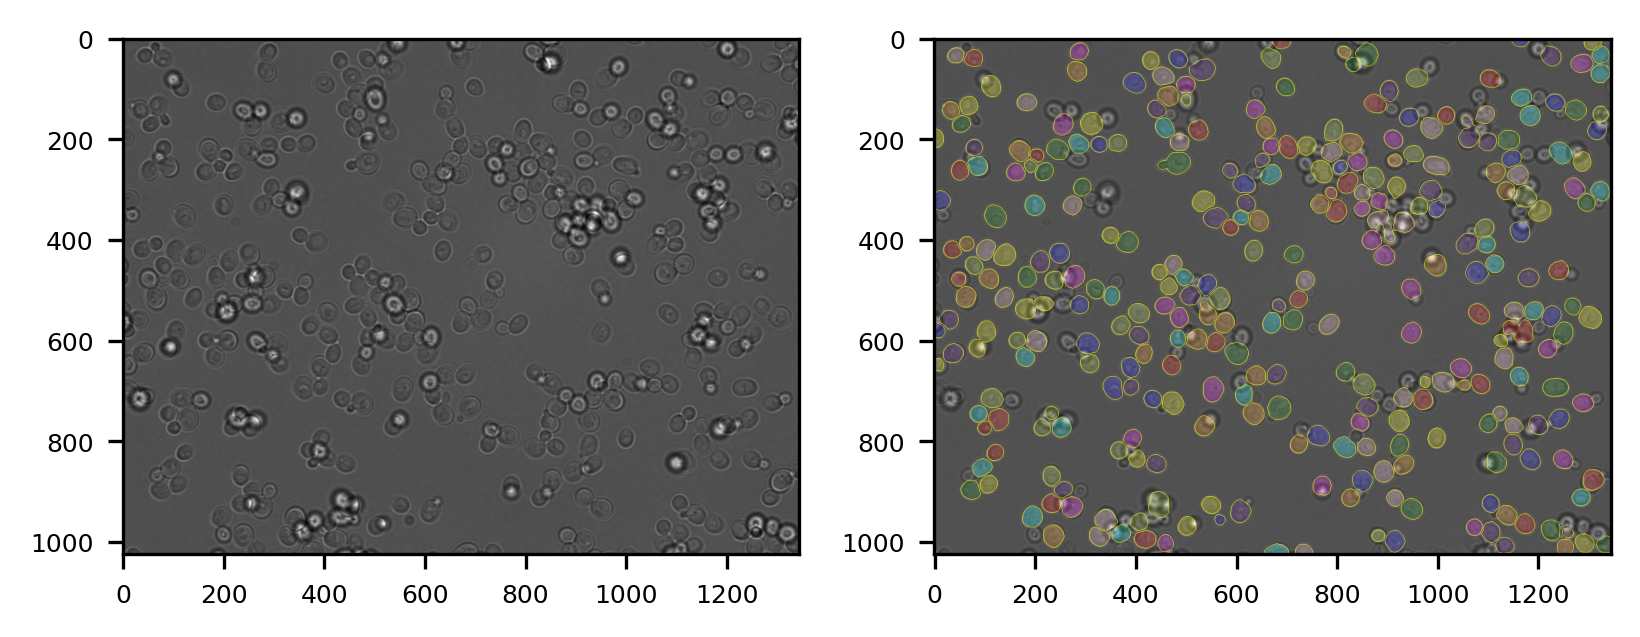

In [7]:
im_display = im / im.mean() * 0.4
im_display[im_display>1] = 1

rgblabel = label2rgb(labels, im_display, kind='overlay', bg_label=0, alpha=0.2) 
boundary_labeled = segmentation.mark_boundaries(rgblabel, labels)

fig = pl.figure(dpi=300)

ax = fig.add_subplot(121)
pl.imshow(im_display, cmap='gray')

ax = fig.add_subplot(122)
pl.imshow(boundary_labeled)

In [ ]:
%%time
im = imread('../sample_images/high_density.tif')
score = model.predict(im)
labels = model.label(score)

CPU times: user 93.3 ms, sys: 62.1 ms, total: 155 ms
Wall time: 899 ms


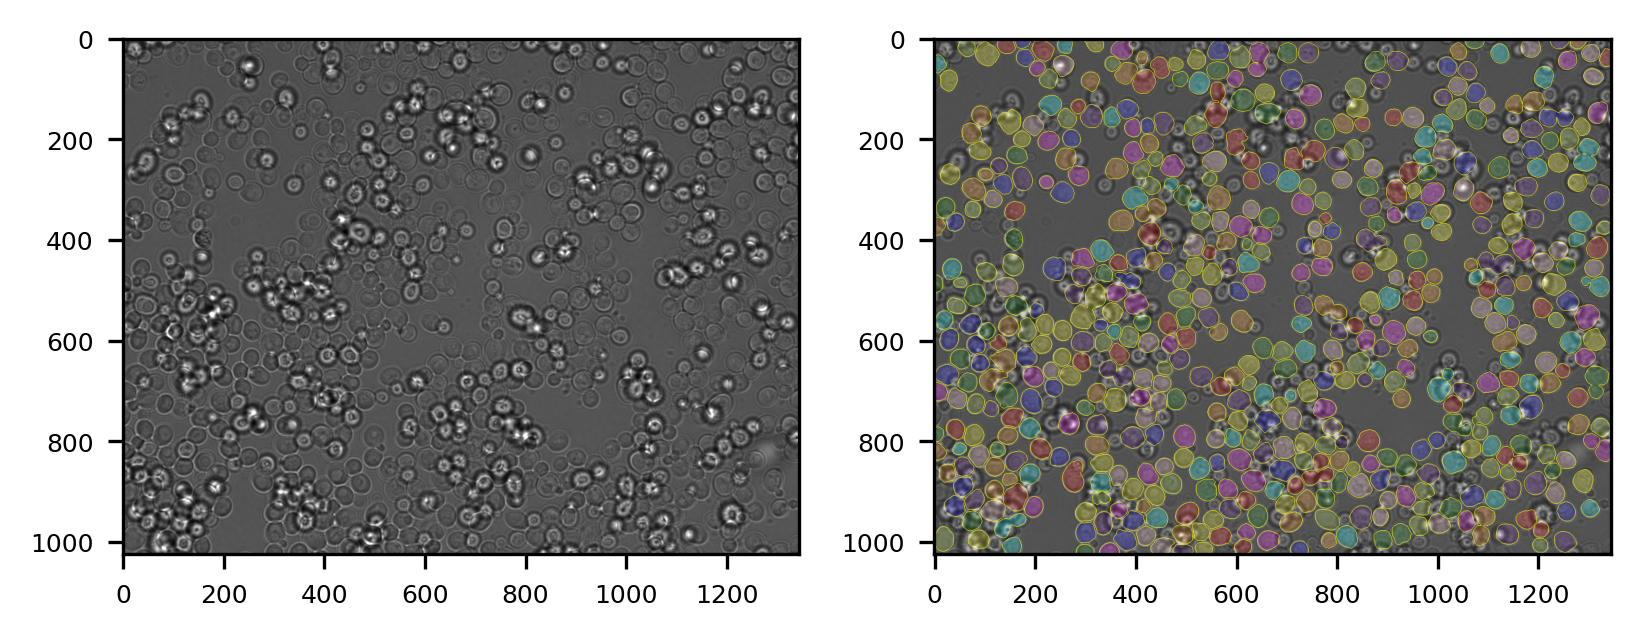

In [9]:
im_display = im / im.mean() * 0.4
im_display[im_display>1] = 1

rgblabel = label2rgb(labels, im_display, kind='overlay', bg_label=0, alpha=0.2) 
boundary_labeled = segmentation.mark_boundaries(rgblabel, labels)

fig = pl.figure(dpi=300)

ax = fig.add_subplot(121)
pl.imshow(im_display, cmap='gray')

ax = fig.add_subplot(122)
pl.imshow(boundary_labeled)

In [ ]:
%%time
im = imread('../sample_images/morphological_variation.tif')
score = model.predict(im)
labels = model.label(score)

CPU times: user 70 ms, sys: 26.5 ms, total: 96.5 ms
Wall time: 885 ms


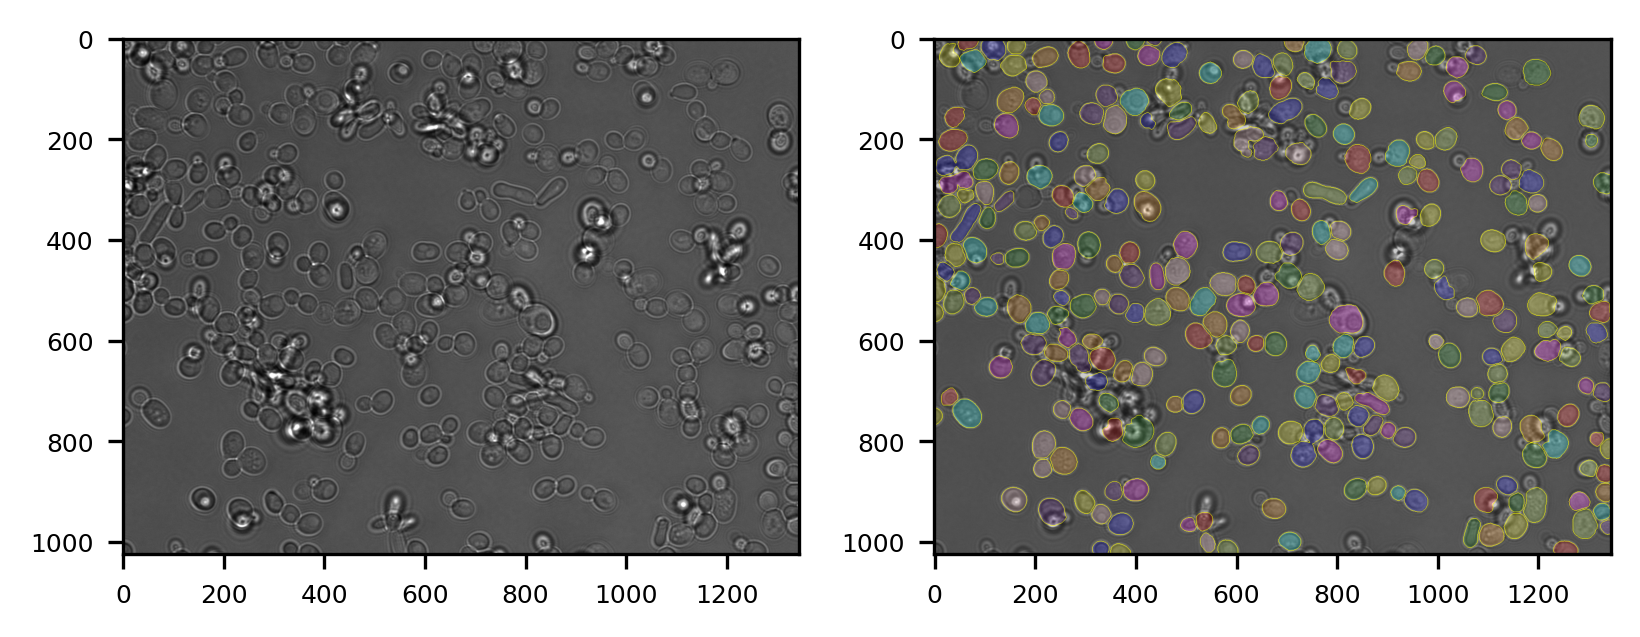

In [11]:
im_display = im / im.mean() * 0.4
im_display[im_display>1] = 1

rgblabel = label2rgb(labels, im_display, kind='overlay', bg_label=0, alpha=0.2) 
boundary_labeled = segmentation.mark_boundaries(rgblabel, labels)

fig = pl.figure(dpi=300)

ax = fig.add_subplot(121)
pl.imshow(im_display, cmap='gray')

ax = fig.add_subplot(122)
pl.imshow(boundary_labeled)